<a href="https://colab.research.google.com/github/MandelaDoondiUshasri/Long-Tail/blob/main/Internship_Roc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import tensorflow as tf
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import get_file
print("Demo by M.D UshaSri,22a81a6136")

Demo by M.D UshaSri,22a81a6136


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Demo by M.D UshaSri,22a81a6136")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Demo by M.D UshaSri,22a81a6136


In [ ]:
import os
import zipfile
#Download and save in google drive from
#URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
# Define the dataset path inside Google Drive
google_drive_path = "/content/drive/MyDrive/DL-Lab/Expt No.6-VGG16/cats_and_dogs_filtered (1).zip"

# Define extraction path (where to extract the dataset)
extract_path = "/content/cats_and_dogs_filtered"

# Verify if the dataset exists
if not os.path.exists(google_drive_path):
    print("❌ Dataset file not found! Check the path in Google Drive.")
else:
    print("✅ Dataset found in Google Drive!")


✅ Dataset found in Google Drive!


In [ ]:
# =========================
if not os.path.exists(extract_path):
    print("🔄 Extracting dataset... Please wait.")
    with zipfile.ZipFile(google_drive_path, 'r') as zip_ref:
        zip_ref.extractall("/content")
    print("✅ Dataset extracted successfully!")
else:
    print("📂 Dataset already extracted.")


In [ ]:
train_dir = os.path.join(extract_path, 'train')
validation_dir = os.path.join(extract_path, 'validation')

# Check if train and validation directories exist
if not os.path.exists(train_dir) or not os.path.exists(validation_dir):
    print("❌ Training or validation directories are missing!")
else:
    print("✅ Training and validation directories exist.")
    print("📂 Training folder contents:", os.listdir(train_dir))
    print("📂 Validation folder contents:", os.listdir(validation_dir))


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Define a sample image path (change 'cats' to 'dogs' if needed)
sample_image_path = os.path.join(train_dir, 'cats', os.listdir(os.path.join(train_dir, 'cats'))[0])

# Load the image using OpenCV
img = cv2.imread(sample_image_path)
print("M.D UshaSri,22a81a6136'Task-6 Dl Lab")

# Check if the image is loaded correctly
if img is None:
    print("❌ Image not loaded! Check the file path.")
else:
    print("✅ Image loaded successfully!")
    print("📏 Image Shape:", img.shape)  # (Height, Width, Channels)

    # Convert BGR to RGB (OpenCV loads images in BGR format)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image to match VGG-16 input size (224x224)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Display the image using Matplotlib (since cv2.imshow() does not work in Colab)
    plt.imshow(img_resized)
    plt.axis("off")  # Hide axes
    plt.title("Sample Cat Image (Resized to 224x224) Demo by M.D UshaSri,22a81a6136")
    plt.show()


In [ ]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0,  # Normalize pixel values (0-255 → 0-1)
    rotation_range=40,  # Rotate images randomly
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,  # Shearing transformation
    zoom_range=0.2,  # Zoom in/out
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest'  # Fill missing pixels after transformation
)

# Validation dataset: Only rescale (no augmentation)
validation_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to VGG-16 input size
    batch_size=16,
    class_mode='binary'  # Binary classification (cats vs dogs)
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the convolutional base (prevents modification of pre-trained weights)
base_model.trainable = False

# Print the base model summary
base_model.summary()



Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout to reduce overfitting
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,560,769 (105.14 MB)

 Trainable params: 12,846,081 (49.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Train the model for 2 epochs
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    verbose=1
)


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 283ms/step - accuracy: 0.6080 - loss: 1.8212 - val_accuracy: 0.8500 - val_loss: 0.3162
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.7985 - loss: 0.4195 - val_accuracy: 0.9120 - val_loss: 0.2282
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 274ms/step - accuracy: 0.8239 - loss: 0.3909 - val_accuracy: 0.8930 - val_loss: 0.2639
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 275ms/step - accuracy: 0.8207 - loss: 0.3723 - val_accuracy: 0.8810 - val_loss: 0.2734
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 283ms/step - accuracy: 0.8545 - loss: 0.3328 - val_accuracy: 0.9160 - val_loss: 0.2253
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 313ms/step - accuracy: 0.8555 - loss: 0.3541 - val_accuracy: 0.9170 - val_loss: 0.2187
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 275ms/step - accuracy: 0.8322 - loss: 0.3626 - val_accuracy: 0.9200 - val_loss: 0.2046
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 275ms/step - accuracy: 0.8664 - loss: 0

In [ ]:
test_loss, test_acc = model.evaluate(validation_generator)
print(f"\n✅ Model Test Accuracy: {test_acc:.2f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.9256 - loss: 0.1961

✅ Model Test Accuracy: 0.94


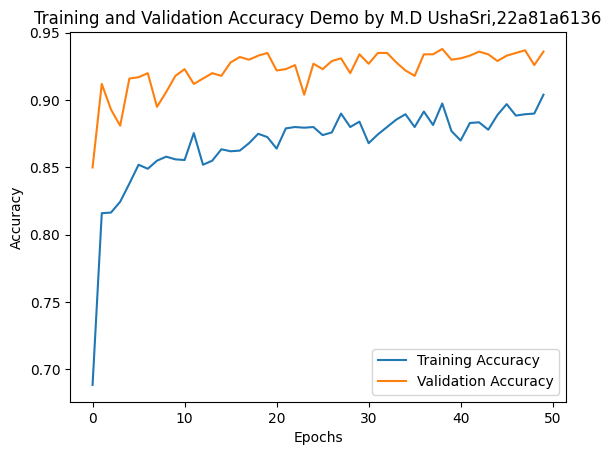

In [ ]:
# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Demo by M.D UshaSri,22a81a6136')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

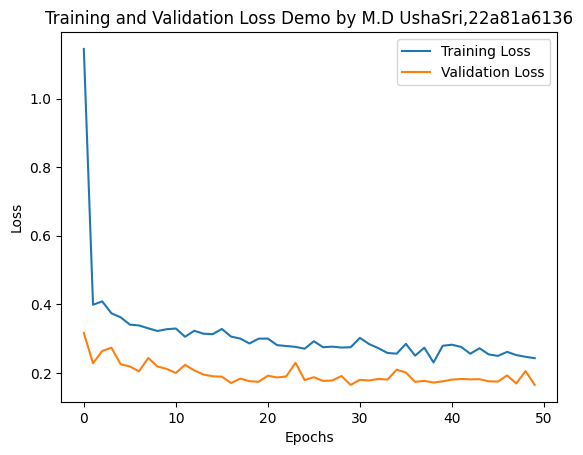

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Demo by M.D UshaSri,22a81a6136')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step
Confusion Matrix:
[[251 249]
 [253 247]]


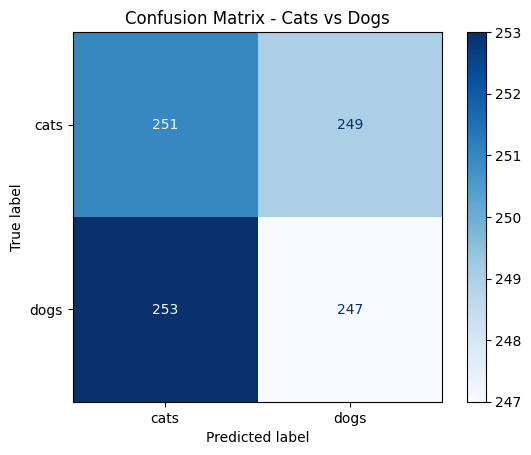

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Step 1: Get true labels and predictions from the validation generator
# Set shuffle=False to maintain order between filenames and labels
validation_generator.reset()  # Important to reset the generator
y_true = validation_generator.classes  # Ground truth labels

# Get model predictions (probabilities)
y_pred_probs = model.predict(validation_generator, verbose=1)

# Convert probabilities to binary labels (0 or 1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Step 2: Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Step 3: Display the confusion matrix
labels = list(validation_generator.class_indices.keys())  # ['cats', 'dogs']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Cats vs Dogs")
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step


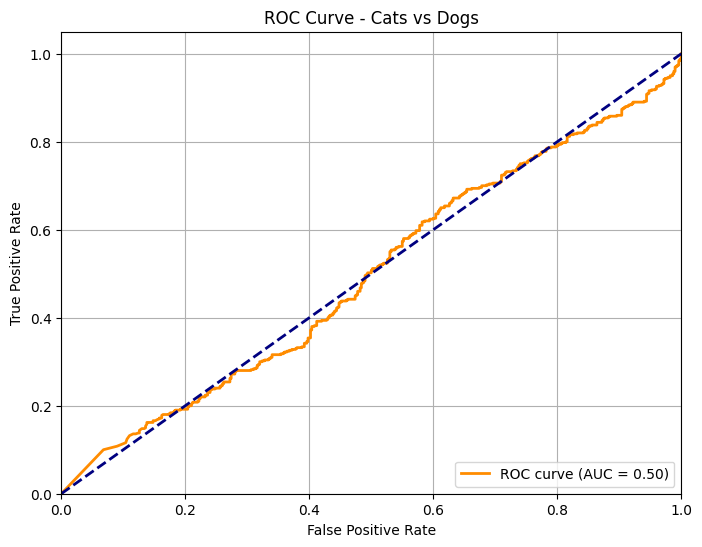

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


validation_generator.reset()

# Get true labels
y_true = validation_generator.classes

# Get predicted probabilities for the positive class (dogs)
y_pred_probs = model.predict(validation_generator, verbose=1).flatten()

# Compute False Positive Rate, True Positive Rate and thresholds
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (random guess)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Cats vs Dogs')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Reset the validation generator to ensure proper label alignment
validation_generator.reset()

# True labels
y_true = validation_generator.classes

# Predicted probabilities
y_pred_probs = model.predict(validation_generator, verbose=1).flatten()

# Convert probabilities to binary predictions
y_pred = (y_pred_probs > 0.5).astype(int)

# Get class labels
class_labels = list(validation_generator.class_indices.keys())  # ['cats', 'dogs']

# Generate and print the classification report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:")
print(report)


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step
Classification Report:
              precision    recall  f1-score   support

        cats       0.52      0.52      0.52       500
        dogs       0.52      0.52      0.52       500

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.52      0.52      0.52      1000

